In [2]:
pip install tensorflow

/Users/All file hear/complete ai /Deep learning/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras import Sequential

In [4]:
(X_train,Y_train),(X_test,Y_test)=keras.datasets.mnist.load_data()

In [5]:
X_train.shape

(60000, 28, 28)

In [6]:
X_test.shape

(10000, 28, 28)

In [7]:
Y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [8]:
import matplotlib.pyplot as plt

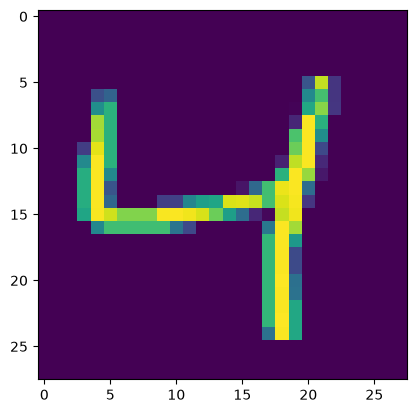

In [9]:
plt.imshow(X_train[2])

In [10]:
X_train.max()

np.uint8(255)

In [11]:
X_train = X_train/255
X_test = X_test/255

In [12]:
model = Sequential()

In [13]:
model.add(Flatten(input_shape= (28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation="softmax"))

/Users/All file hear/complete ai /Deep learning/.venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [17]:
history = model.fit(X_train,Y_train,epochs=100,validation_split=.2)

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - accuracy: 0.9984 - loss: 0.0049 - val_accuracy: 0.9766 - val_loss: 0.1441
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 809us/step - accuracy: 0.9993 - loss: 0.0026 - val_accuracy: 0.9793 - val_loss: 0.1226
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 786us/step - accuracy: 0.9984 - loss: 0.0051 - val_accuracy: 0.9778 - val_loss: 0.1288
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 800us/step - accuracy: 0.9992 - loss: 0.0031 - val_accuracy: 0.9755 - val_loss: 0.1535
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 796us/step - accuracy: 0.9987 - loss: 0.0044 - val_accuracy: 0.9753 - val_loss: 0.1555
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 773us/step - accuracy: 0.9987 - loss: 0.0038 - val_accuracy: 0.9780 - val_loss: 0.1334
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 813us/step - accuracy: 0.9994 - loss: 0.0018 - val_accuracy: 0.9759 - val_loss: 0.1481
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 781us/step - accuracy: 

In [18]:
Y_pred = model.predict(X_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 310us/step


In [28]:
y_final=Y_pred.argmax(axis=1)
print(y_final)
print(Y_test)

[7 2 1 ... 4 5 6]
[7 2 1 ... 4 5 6]


In [24]:
Y_pred[0] 

array([2.8897820e-28, 8.3865891e-35, 3.0614669e-27, 1.0725574e-14,
       0.0000000e+00, 5.8111000e-29, 1.2416426e-36, 1.0000000e+00,
       3.9397575e-25, 5.7245372e-24], dtype=float32)

In [ ]:

from sklearn.metrics import accuracy_score


In [22]:
accuracy_score(Y_test,y_final)

0.9807

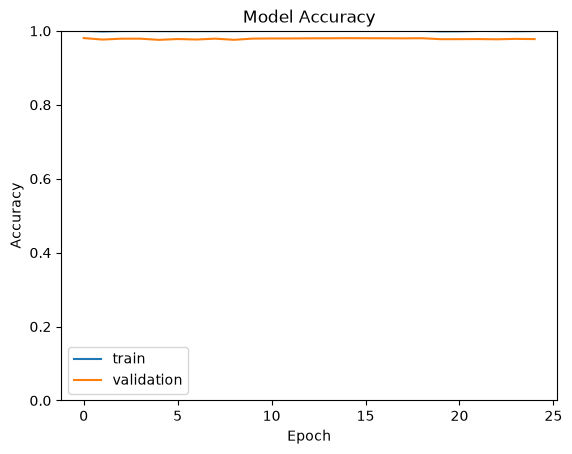

In [54]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['train', 'validation'])
plt.ylim(0,1)

plt.show()

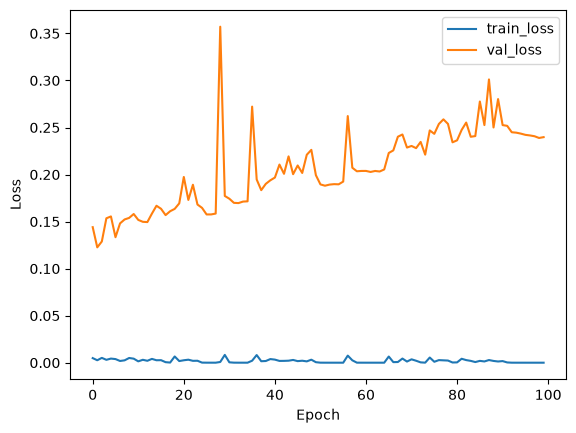

In [23]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()